# Using Inverse Volatility in Passive Sector Rotation
This strategy utilizes inverse volatility weighting as a passive approach to sector rotation, with monthly rebalancing based on the preceding 12 months of historical returns. The core principle behind this method is to manage portfolio risk by systematically adjusting sector exposures in accordance with their historical volatility, rather than relying on predictive models or active forecasts.
Volatility serves as a proxy for risk. By assigning lower weights to more volatile sectors and higher weights to more stable sectors, the strategy aims to achieve a more balanced risk profile across the portfolio. This is conceptually aligned with risk-parity frameworks, where the objective is not merely to diversify capital but to equalize risk contribution from each component.
The use of a rolling 12-month window ensures that allocations are continuously updated to reflect the latest market conditions. Each month, sector volatilities are recalculated, and portfolio weights are adjusted accordingly. This approach facilitates a mechanical form of sector rotation, where shifts in exposure are driven purely by observed changes in volatility.
One of the key advantages of this strategy is its simplicity and transparency. It avoids the need for subjective judgments or market timing, making it well-suited to passive investment mandates. Moreover, extensive empirical research has shown that low-volatility strategies tend to outperform on a risk-adjusted basis, particularly in periods of heightened market uncertainty.
In summary, inverse volatility weighting provides a disciplined, risk-aware framework for sector rotation. By rebalancing monthly using a backward-looking measure of volatility, the strategy promotes portfolio stability and adaptability while maintaining the core tenets of passive investing.

# Using Relative Strength for Active Sector Rotation
The intuition behind using Relative Strength for industry selection is based on Julius de Kempenaer's Relative Rotation Graph (RRG). The goal is to separate the market leaders from the market laggards. Note that Relative Strength here is not the same as Relative Strength Index RSI. Two inputs are evaluated simutaneously in Relative Strength analysis: RS ratio and RS momentum. Together, these two inputs depict the relative strength trends of several securities against a common benchmark.
More information of RRG here: https://chartschool.stockcharts.com/table-of-contents/chart-analysis/chart-types/relative-rotation-graphs-rrg-charts#jdk_rs-momentum
 
## Relative Strength Ratio
Relative Strength ratio (RS) is calculated as Asset Price/Benchmark Price. The trend of the RS ratio measures the relative performance of the Asset with the Benchmark.
 
RS ratio will be calculated as the price of each industry ETF with the price of the market ETF. To account for the large differences in price scales of different industries that can skew the RS line, the ratios will be normalized to a common pseudo starting price value of 100 for all industries and the benchmark. In other words, RS ratios of all industries will start at 1.
 
This indicator reflects an uptrend in relative performance when above 1 (relative strength) and a downtrend in relative performance when below 1 (relative weakness). The further the indicator is above 1, the stronger the uptrend in relative performance. The further the indicator is below 1, the stronger the downtrend in relative performance.
## Relative Strength Momentum
RS Momentum is the rate of change of RS ratios. As a momentum indicator, it leads RS-Ratio, and can be used to anticipate turns in RS-Ratio. In other words, RS-Momentum is an indicator of an indicator (RS-Ratio). Typically, RS-Momentum crosses above 1 when RS-Ratio is forming a trough and starting to move up. Conversely, RS-Momentum crosses below 1 when RS-Ratio is forming a peak and starting to move down.
 
## RS application
Based on RS ratio and RS momentum, the industries can be classified into 4 groups:

RS ratio > 1 and RS momentum > 1: leading

RS ratio > 1 and RS momentum < 1: weakening

RS ratio < 1 and RS momentum < 1: lagging

RS ratio < 1 and RS momentum > 1: improving

We will long industries in the improving categories and short those in the weakening categories.

# Using MACD as moment signal from the market
The MACD (Moving Average Convergence Divergence) indicator is a widely used momentum oscillator that helps identify trend direction and strength. It helps identify trend direction, potential reversals, and entry/exit points. We have used the MACD to generate binary trading signals that determine whether to follow the RS-based active strategy or default to an inverse volatility strategy. By doing so, the MACD acts as a risk filter, helping to avoid poor-performing periods when market momentum is weak. This enhances the portfolio’s dynamic adaptability by switching between aggressive and conservative strategies based on market conditions. Ultimately, the MACD improves the strategy’s responsiveness to trend changes and contributes to more informed allocation decisions. 

We use the MACD signal from the market to implement the Relative Strength Dynamic strategy: whenever MACD suggests a significant movement in the market, we use Relative Strength for industry allocation; otherwise, we allocate the industry weight in accordance to Inverse Volatility strategy.

# Performance Analysis
We compare the performance of four strategies: (1) Equal Weighted, (2) Inverse Volatility, (3) Relative Strength, and (4) Relative Strength Dynamic.

![](table.jpeg)
 
Among the four strategies, Relative Strength and Relative Strength Dynamic outperform the other two in both absolute and risk-adjusted returns. Specifically, both Equal Weighted and Inverse Volatility have 10.8% CAGR, whereas Relative Strength and Relative Strength Dynamic have 20-30% higher CAGR at 12.2% and 13.2% respectively. In terms of risk-adjusted returns, all four strategies have relatively similar Sharpe ratio, and Relative Strength has the highest at 0.48.
In conclusion, Relative Strength is the most outperforming strategy in terms of both absolute return and risk-adjusted return.

![](Strategy_performance.png)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

In [2]:
ff3 = pd.read_csv('data_ff3.csv')
ff3 = ff3.drop_duplicates(subset='Date').reset_index(drop=True)
ff3[ff3.columns.drop('Date')] = ff3[ff3.columns.drop('Date')].apply(pd.to_numeric, errors='coerce')
ind49 = pd.read_csv('data_ind49.csv')
ind49 = ind49.drop_duplicates(subset='Date').reset_index(drop=True)
ind49[ind49.columns.drop('Date')] = ind49[ind49.columns.drop('Date')].apply(pd.to_numeric, errors='coerce')

# Align dates between both files
common_dates = ff3['Date'].isin(ind49['Date'])
ff3 = ff3[common_dates].reset_index(drop=True)
ind49 = ind49[ind49['Date'].isin(ff3['Date'])].reset_index(drop=True)

In [3]:
# Converting columns to numeric and dropping non-numeric rows
ff3['Mkt-RF'] = pd.to_numeric(ff3['Mkt-RF'], errors='coerce')
ff3['RF'] = pd.to_numeric(ff3['RF'], errors='coerce')
ff3['Mkt'] = ff3['Mkt-RF'] + ff3['RF']
ff3 = ff3.dropna(subset=['Mkt'])  # drops any rows that couldn't convert
dates = ff3['Date']
market_data = ff3['Mkt'].values

#Calculating Market Return
ff3['Mkt'] = ff3['Mkt-RF'] + ff3['RF']
dates = ff3['Date']
market_data = ff3['Mkt'].values

#Defining EMA Function 
def ema_numpy(data, span):
    alpha = 2 / (span + 1)
    ema = np.zeros_like(data)
    ema[0] = data[0]
    for t in range(1, len(data)):
        ema[t] = alpha * data[t] + (1 - alpha) * ema[t - 1]
    return ema

#Calculating MACD and Signal Line
ema_12 = ema_numpy(market_data, 12)
ema_26 = ema_numpy(market_data, 26)
macd_line = ema_12 - ema_26
signal_line = ema_numpy(macd_line, 9)
hist = macd_line - signal_line

# Rule: Exit if histogram is < 0.05
entry_signal = np.where(hist < 0.05, 0, 1)

#Creating Final DataFrame 
market_macd_df = pd.DataFrame({
    'Date': dates,
    'Market_MACD': macd_line,
    'Market_Signal': signal_line,
    'Market_Hist': hist,
    'Market_TradeSignal_Binary': entry_signal
})
market_macd_df.set_index('Date', inplace=True)

In [4]:
# Replacing -99.99 values with NaN
ind49.replace(-99.99, np.nan, inplace=True)
merged_data = pd.merge(ff3, ind49, on='Date',how='inner')
industry = merged_data[ind49.columns]
industry.set_index('Date', inplace=True)

# Converting percentage returns to decimal form
industry = industry.apply(pd.to_numeric, errors='coerce') / 100

In [5]:
# Initializing the rolling strategy returns Series
rolling_strategy_returns = pd.Series(index=industry.index, dtype=float)

# Start after 12 months of data
for i in range(11, len(industry) - 1):
    current_date = industry.index[i]
    
    # 12-month window of past returns
    past_window = industry.iloc[i - 11 : i + 1]

    # Dropping columns with any missing data in the window
    past_window_clean = past_window.dropna(axis=1)
    if past_window_clean.shape[1] == 0:
        continue

    # Calculating inverse volatility weights
    vol = past_window_clean.std()
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    # Applying weights to next month's returns
    next_date = industry.index[i + 1]
    next_month_returns = industry.loc[next_date, past_window_clean.columns]
    if isinstance(next_month_returns, pd.DataFrame):
        next_month_returns = next_month_returns.iloc[0]

    next_month_returns = next_month_returns.fillna(0)       

    # Computing portfolio return
    rolling_strategy_returns.loc[next_date] = np.dot(weights, next_month_returns)

In [6]:
# Calculating RS Ratio
RS_ratio = pd.merge(ff3[['Date','Mkt']], ind49, on='Date',how='inner')
RS_ratio.iloc[:,1:] = (RS_ratio.iloc[:,1:].div(100).add(1).cumprod())*100
RS_ratio.iloc[:,1:] = RS_ratio.iloc[:,1:].div(RS_ratio['Mkt'], axis=0)
RS_ratio = RS_ratio.set_index('Date')
 
# Calculating RS Momentum
RS_momentum = RS_ratio.pct_change(fill_method=None).add(1)
 
# Creating a DataFrame of active positions on each industry based on RS signals
active_position = np.select(
            condlist = [
                (RS_ratio.iloc[:,1:].shift(1) < 1) & (RS_momentum.iloc[:,1:].shift(1) > 1),
                (RS_ratio.iloc[:,1:].shift(1) < 1) & (RS_momentum.iloc[:,1:].shift(1) < 1),
                (RS_ratio.iloc[:,1:].shift(1) > 1) & (RS_momentum.iloc[:,1:].shift(1) < 1),
                (RS_ratio.iloc[:,1:].shift(1) > 1) & (RS_momentum.iloc[:,1:].shift(1) > 1)
            ],
            choicelist = [1,0,-1,0]
)
active_columns = pd.Series(RS_ratio.iloc[:,1:].columns)
active_position = pd.DataFrame(active_position, index=RS_momentum.index, columns = active_columns)
 
#Counting the total number of long and short positions for each date
active_position = active_position.assign(
    total_long = lambda x: x.apply(lambda y: (y==1).sum(), axis = 1),
    total_short = lambda x: x.apply(lambda y: (y==-1).sum(), axis = 1)
)

In [7]:
industry_returns = ind49.set_index('Date').div(100)  # daily or monthly industry returns
common_index = industry_returns.index.intersection(active_position.index)
common_cols = industry_returns.columns.intersection(active_position.columns.drop(['total_long','total_short']))

industry_returns = industry_returns.loc[common_index, common_cols]
active_position = active_position.loc[common_index, list(common_cols) + ['total_long','total_short']]
signals = active_position[common_cols]

# Return from long positions only
long_returns = industry_returns.where(signals == 1, 0)
# Return from short positions only
short_returns = industry_returns.where(signals == -1, 0)

active_return = pd.DataFrame(index=industry_returns.index)

# Get number of positions

active_return['total_long'] = active_position['total_long']
active_return['total_short'] = active_position['total_short'].clip(upper=active_return['total_long'] * (0.3/0.7))

# Avoid divide-by-zero
longs = active_return['total_long'].replace(0, np.nan)
shorts = active_return['total_short'].replace(0, np.nan)

# Total adjusted positions (after clipping)
total_positions = longs + shorts

# Compute actual weights
active_return['long_weight'] = longs / total_positions
active_return['short_weight'] = shorts / total_positions

In [8]:

# Master alignment before any strategy calculations
common_index = industry_returns.index.intersection(active_position.index)
common_cols = industry_returns.columns.intersection(active_position.columns.drop(['total_long','total_short']))

industry_returns = industry_returns.loc[common_index, common_cols]
active_position = active_position.loc[common_index, list(common_cols) + ['total_long','total_short']]
signals = active_position[common_cols]  # <-- now this replaces your old signals line


In [9]:
# Get Sum of long and short returns
active_return['long_total_return'] = long_returns.sum(axis=1)
active_return['short_total_return'] = short_returns.sum(axis=1) 

active_return['long_avg_return'] = active_return['long_total_return'] / active_return['total_long'].replace(0, np.nan)
active_return['short_avg_return'] = active_return['short_total_return'] / active_return['total_short'].replace(0, np.nan)

active_return['returns'] = (
    active_return['long_avg_return'].fillna(0) * active_return['long_weight'] +
    active_return['short_avg_return'].fillna(0) * active_return['short_weight']
)

In [10]:
portfolio = pd.concat([market_macd_df['Market_TradeSignal_Binary'],active_return['returns'],rolling_strategy_returns],axis=1)

In [11]:
portfolio=portfolio.rename(columns={'Market_TradeSignal_Binary':'Market_signal','returns':'RS_returns',0:'Inv_vol_returns'})
portfolio=portfolio.dropna()

In [12]:
portfolio['Portfolio_returns'] = np.select(
    condlist = [
        portfolio['Market_signal'].shift(1) == 1, 
        portfolio['Market_signal'].shift(1) != 1
    ],
    choicelist = [portfolio['RS_returns'],portfolio['Inv_vol_returns']]
)
portfolio['Equal_weight_returns'] = ind49.set_index('Date').div(100).mean(axis=1)

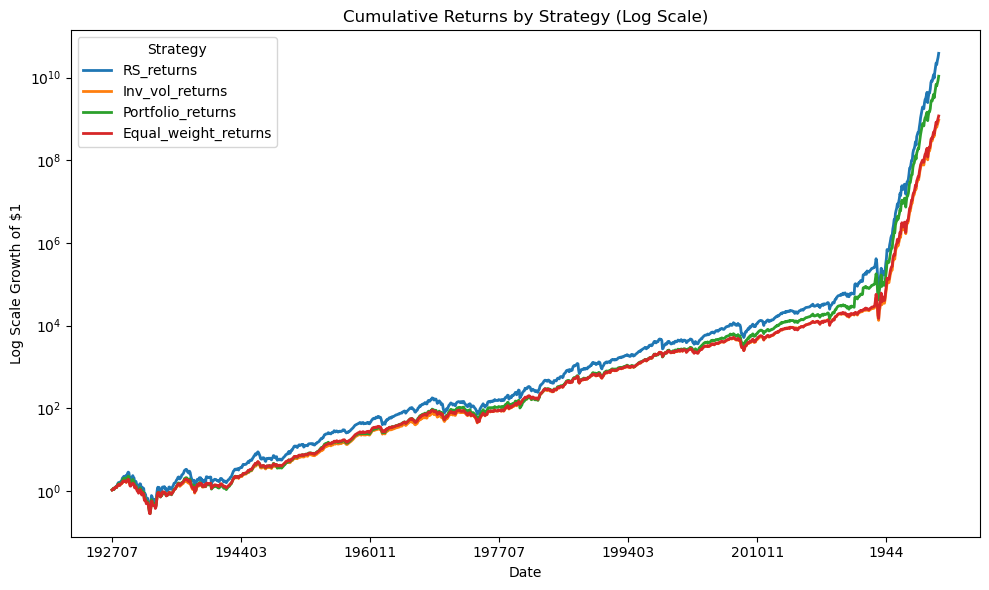

In [13]:
cumulative = portfolio[['RS_returns', 'Inv_vol_returns', 'Portfolio_returns', 'Equal_weight_returns']].add(1).cumprod()
cumulative.plot(logy=True, figsize=(10, 6), linewidth=2)
plt.title("Cumulative Returns by Strategy (Log Scale)")
plt.ylabel("Log Scale Growth of $1")
plt.xlabel("Date")
plt.legend(title="Strategy")
plt.tight_layout()
plt.savefig("Strategy_performance.png", dpi=300, bbox_inches='tight')
plt.show()

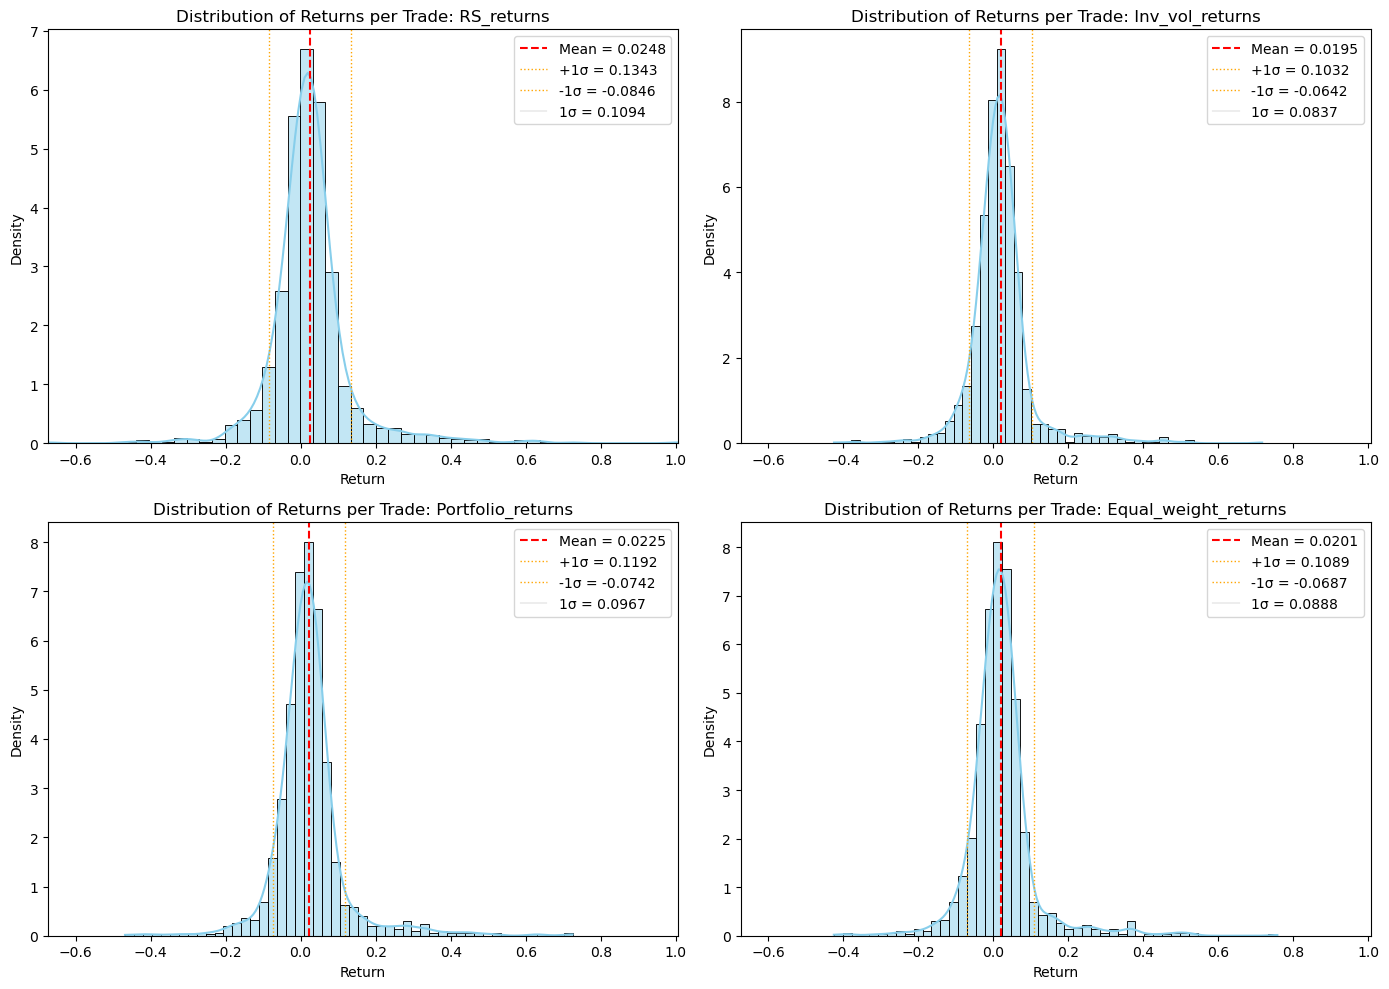

In [14]:
strategy_cols = ['RS_returns', 'Inv_vol_returns', 'Portfolio_returns', 'Equal_weight_returns']
 
# Determine global x-axis limits
xmin = min(portfolio[col].min() for col in strategy_cols)
xmax = max(portfolio[col].max() for col in strategy_cols)
 
plt.figure(figsize=(14, 10))
for i, col in enumerate(strategy_cols, 1):
    data = portfolio[col].dropna()
    mean = data.mean()
    std = data.std()
 
    plt.subplot(2, 2, i)
    sns.histplot(data, bins=50, kde=True, stat='density', color='skyblue')
    # Plot mean and ±1 std lines
    plt.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean:.4f}')
    plt.axvline(mean + std, color='orange', linestyle=':', linewidth=1, label=f'+1σ = {mean + std:.4f}')
    plt.axvline(mean - std, color='orange', linestyle=':', linewidth=1, label=f'-1σ = {mean - std:.4f}')
    plt.plot([], [], color='black', linewidth=0.1, label=f'1σ = {std:.4f}')  # Invisible line for legend
 
    # Fixed x-axis limits for all subplots
    plt.xlim(xmin, xmax)
 
    plt.title(f'Distribution of Returns per Trade: {col}')
    plt.xlabel("Return")
    plt.ylabel("Density")
    plt.legend()
 
plt.tight_layout()
plt.show()

In [ ]:
ff3 = ff3.set_index('Date').div(100)
portfolio = portfolio[pd.to_numeric(portfolio.index, errors='coerce').notna()]
portfolio = pd.concat([portfolio, ff3['RF']], axis=1, join='inner')
portfolio.index = pd.to_datetime(portfolio.index.astype(str), format='%Y%m')
annual_returns = (portfolio[['Equal_weight_returns', 'Inv_vol_returns','RS_returns', 'Portfolio_returns', 'RF']] + 1).resample('Y').prod() - 1


TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [ ]:
def cagr(series):
    return (series.add(1).prod() ** (1 / len(series)) - 1) * 100

def sharpe_ratio(series, risk_free_rate):
    excess = series - risk_free_rate
    return excess.mean() / series.std()

results = pd.DataFrame({
    "Strategy": ["Equal Weighted", "Inverse Volatility", "RS_Strat", "RS + IV (Dynamic)"],
    "CAGR (%)": [
        cagr(annual_returns["Equal_weight_returns"]),
        cagr(annual_returns["Inv_vol_returns"]),
        cagr(annual_returns["RS_returns"]),
        cagr(annual_returns["Portfolio_returns"]),
    ],
    "Sharpe Ratio": [
        sharpe_ratio(annual_returns["Equal_weight_returns"], annual_returns['RF']),
        sharpe_ratio(annual_returns["Inv_vol_returns"], annual_returns['RF']),
        sharpe_ratio(annual_returns["RS_returns"], annual_returns['RF']),
        sharpe_ratio(annual_returns["Portfolio_returns"], annual_returns['RF']),
    ]
})

def render_markdown_table(df):
    table = df.to_markdown(index=False)
    display(Markdown(f"**Strategy Performance Summary (Annualized)**\n\n{table}"))

render_markdown_table(results)

In [ ]:
portfolio.index = pd.to_datetime(portfolio.index)  # just in case it's not already
portfolio.index = portfolio.index.to_period('M')

In [ ]:
portfolio['RS_returns'].to_csv('Group_01.csv')